# Regression — Exercise 3.2: Predicting Fish Weight with Feature Engineering

**Course:** Introduction to Machine Learning and Applied Artificial Intelligence
**Institution:** High School of Digital Culture, ITMO University



This notebook builds a linear regression model to predict fish weight from physical
measurements, and — more importantly — demonstrates how much **feature engineering**
(rather than a fancier model) can improve a simple linear model's performance. We go
through four stages: a naive baseline, dimensionality reduction with PCA, a
physics-motivated non-linear transform, and one-hot encoding of a categorical feature.

For reference, the [scikit-learn LinearRegression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
describes `LinearRegression().fit(X, y)`, which we use with default settings
throughout.


## Task

The [dataset](https://storage.yandexcloud.net/lms-itmo-ru-files-27a87tyf/machine_learning/task3/task3.2/data/fish_train.csv)
contains measurements of seven species of fish sold at a fish market. The goal is to
predict `Weight` from the other (physical + categorical) features. The full dataset
has 159 objects; here we work with a 119-object training subset reserved for this
exercise.

We'll build the model in four increasingly sophisticated stages:

0. Load the data and split it into train/test sets.
1. **Baseline** — linear regression using only the numeric features, as-is.
2. **PCA on correlated features** — collapse three highly-correlated length
   measurements into a single principal component.
3. **Feature engineering (cubing)** — apply a physics-motivated cube transform to
   linear measurements, since mass scales with volume, not length.
4. **Categorical features** — one-hot encode the fish species and add it back in.

At each stage we evaluate the model with `r2_score()` on the held-out test set.


## 0. Setup and data loading


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [2]:
DATA_URL = "https://storage.yandexcloud.net/lms-itmo-ru-files-27a87tyf/machine_learning/task3/task3.2/data/fish_train.csv"

data = pd.read_csv(DATA_URL, encoding="utf-8", delimiter=",")
data.head()


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Roach,150.0,20.4,22.0,24.7,5.8045,3.7544
1,Perch,250.0,25.4,27.5,28.9,7.2828,4.5662
2,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
3,Bream,925.0,36.2,39.5,45.3,18.7542,6.7497
4,Perch,110.0,19.0,21.0,22.5,5.6925,3.5550


### Train / test split

We split off 20% of the data for testing, stratifying by `Species` so that each fish
species is proportionally represented in both the training and test sets (important
since some species are rarer than others).


In [3]:
train, test = train_test_split(
    data, test_size=0.2, random_state=11, stratify=data["Species"]
)

# Quick check: sample mean of the Width column in the training split.
print(f"Sample mean of Width (train): {round(np.mean(train['Width']), 3)}")


Sample mean of Width (train): 4.498


## 1. Baseline model: numeric features only

As a first approximation, we drop the categorical `Species` column and fit a plain
linear regression on the remaining numeric measurements.


In [4]:
species_train = train["Species"]
y_train = train[["Weight"]]
train = train.drop(columns=["Species", "Weight"])

species_test = test["Species"]
y_test = test[["Weight"]]
test = test.drop(columns=["Species", "Weight"])


In [5]:
baseline_model = LinearRegression().fit(train, y_train)
y_pred_baseline = baseline_model.predict(test)

print(f"Baseline R^2 (numeric features only): {round(r2_score(y_test, y_pred_baseline), 3)}")


Baseline R^2 (numeric features only): 0.824


## 2. Feature preprocessing with PCA

### Inspect correlations

Fish body-length measurements (`Length1`, `Length2`, `Length3` — likely different
length definitions such as standard/fork/total length) are expected to be highly
correlated with each other. A correlation heatmap confirms this and tells us which
features are effectively redundant.


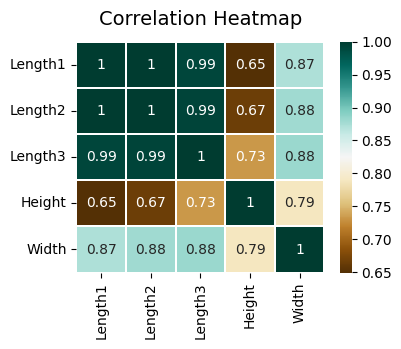

In [6]:
plt.figure(figsize=(4, 3))
heatmap = sns.heatmap(train.corr(), annot=True, cmap="BrBG", linewidths=0.1)
heatmap.set_title("Correlation Heatmap", fontdict={"fontsize": 14}, pad=12)
plt.show()


The heatmap confirms that `Length1`, `Length2`, and `Length3` are the three most
strongly correlated features — as expected, since they are all different ways of
measuring how long the fish is.


In [7]:
corr_features = train[["Length1", "Length2", "Length3"]]
corr_features.head()


,Length1,Length2,Length3
97,23.6,25.2,27.9
37,40.2,43.5,46.0
21,37.0,40.0,42.5
40,21.2,23.0,25.8
116,37.3,40.0,43.5


### Collapse the three length features into one principal component

Instead of dropping two of the three redundant length features outright (losing
information), we use PCA to combine all three into a single feature (`Len`) that
captures the shared "fish length" signal, using only the first principal component.


In [8]:
pca = PCA(n_components=3, svd_solver="full").fit(corr_features)
df_train = pca.transform(corr_features)
df1 = pd.DataFrame(df_train, columns=["PC1", "PC2", "PC3"])
df1.head()


,PC1,PC2,PC3
0,-5.647250,-0.051676,-0.250579
1,24.959486,-1.087435,0.213041
2,19.068600,-0.906179,0.145159
3,-9.496090,0.340029,-0.043217
4,19.848407,-0.282176,-0.159015


In [9]:
print(
    "Explained variance ratio using only the first principal component: "
    f"{round(pca.explained_variance_ratio_[0], 3)}"
)


Explained variance ratio using only the first principal component: 0.996


A single component already captures the vast majority of the variance across the
three length measurements — strong confirmation that they're measuring essentially the
same underlying quantity.

Now we apply the *same* fitted PCA transform to the test set (never re-fit PCA on test
data — that would leak information) and replace the three length columns with the
single `Len` feature in both the training and test sets.


In [10]:
# Replace the correlated length features with a single PCA-derived "Len" feature
train = train.drop(columns=["Length1", "Length2", "Length3"])
train["Len"] = df1["PC1"].tolist()
train.head()


,Height,Width,Len
97,7.0866,3.9060,-5.647250
37,12.6040,8.1420,24.959486
21,11.7300,7.2250,19.068600
40,10.3458,3.6636,-9.496090
116,12.3540,6.5250,19.848407


In [11]:
corr_features_test = test[["Length1", "Length2", "Length3"]]
df_test = pca.transform(corr_features_test)
df2 = pd.DataFrame(df_test, columns=["PC1", "PC2", "PC3"])

test = test.drop(columns=["Length1", "Length2", "Length3"])
test["Len"] = df2["PC1"].tolist()
test.head()


,Height,Width,Len
71,6.2750,3.7250,-9.543681
106,2.4300,1.2690,-28.287395
23,6.9153,3.6312,-8.280821
91,5.2224,3.3216,-19.131812
104,5.7078,4.1580,9.874373


### Re-train and evaluate


In [12]:
pca_model = LinearRegression().fit(train, y_train)
y_pred_pca = pca_model.predict(test)

print(f"R^2 after PCA feature reduction: {round(r2_score(y_test, y_pred_pca), 3)}")


R^2 after PCA feature reduction: 0.821


The quality of the model hasn't changed significantly compared to the baseline — which
makes sense, since PCA here is essentially just a lossless-ish compression of
information that was already present in the three length columns. It reduces
dimensionality and multicollinearity, but doesn't add new predictive information.


## 3. Feature engineering: a physics-motivated cube transform

### Why the relationship looks non-linear

Let's plot each feature against `Weight` to see how well a *linear* relationship fits
the data.


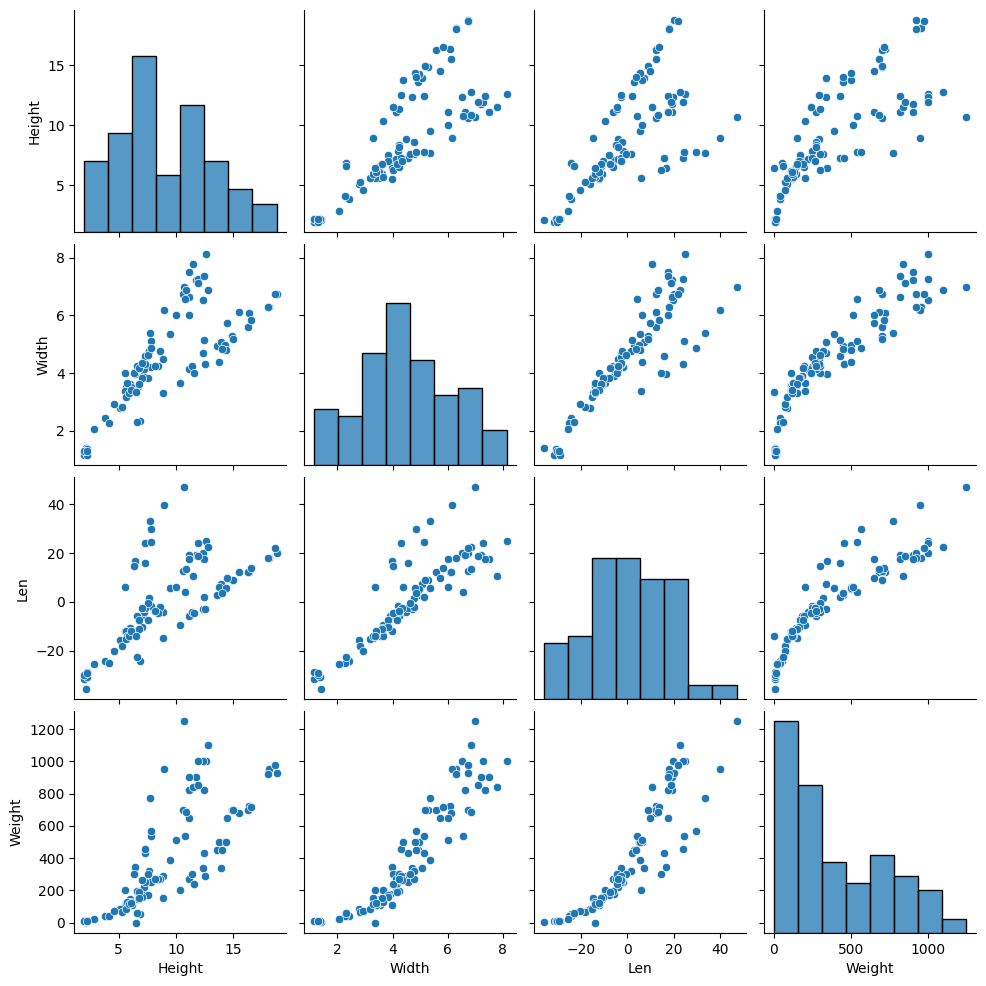

In [13]:
train_plot = train.copy(deep=True)
train_plot["Weight"] = y_train["Weight"].tolist()
sns.pairplot(train_plot)
plt.show()


The pairplot shows that `Weight` does **not** depend linearly on the other features —
the relationships curve upward. So a linear model applied directly to raw length/width/
height measurements is fundamentally mismatched to the shape of the data. To fix this,
we should transform the *features* so that their relationship with `Weight` becomes
more linear, rather than reaching for a more complex (and harder to interpret) model.

### The physics argument

Mass is density times volume:

$$
m = \rho \cdot V
$$

If we assume the average density is roughly the same across fish of similar shape, and
recall that under a simple scaling (homothety) volume scales as the **cube** of linear
dimensions, then weight should scale roughly with the *cube* of length-like
measurements (`Width`, `Height`, `Len`) rather than linearly with them. So we
engineer new features by cubing these three columns.


In [14]:
train_cube = train.copy(deep=True)
train_cube["Width"] = train["Width"] ** 3
train_cube["Height"] = train["Height"] ** 3
train_cube["Len"] = train["Len"] ** 3
train_cube.head()


,Height,Width,Len
97,355.888340,59.593201,-180.098859
37,2002.281725,539.750799,15549.159035
21,1613.964717,377.149516,6933.562190
40,1107.368679,49.172711,-856.316681
116,1885.483738,277.805953,7819.463223


In [15]:
# Sample mean of the (pre-cubing) Width column, for reference.
print(f"Sample mean of Width before cubing: {round(train['Width'].mean(), 3)}")


Sample mean of Width before cubing: 4.498


### Visual check: before vs. after

Comparing the raw `Width` vs. `Weight` relationship shows the same curvature we saw in
the pairplot above; after cubing `Width`, the relationship with `Weight` should look
noticeably straighter (not shown as a second plot here, but worth trying as an
exercise: `sns.scatterplot(x=train_cube['Width'], y=y_train['Weight'])`).


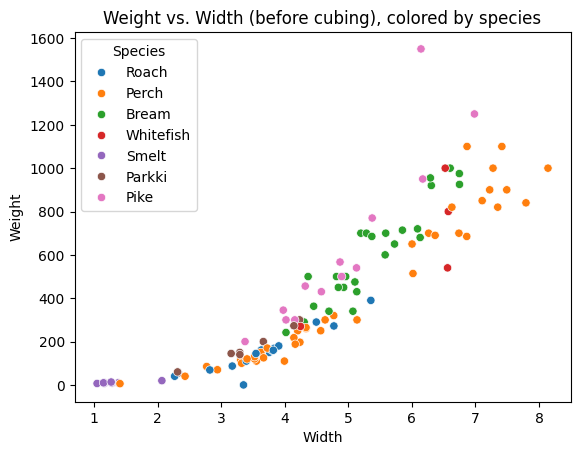

In [16]:
sns.scatterplot(data=data, x="Width", y="Weight", hue="Species")
plt.title("Weight vs. Width (before cubing), colored by species")
plt.show()


### Apply the same transform to the test set and re-evaluate


In [17]:
test_cube = test.copy(deep=True)
test_cube["Width"] = test["Width"] ** 3
test_cube["Height"] = test["Height"] ** 3
test_cube["Len"] = test["Len"] ** 3


In [18]:
cube_model = LinearRegression().fit(train_cube, y_train)
y_pred_cube = cube_model.predict(test_cube)

print(f"R^2 after cube feature engineering: {round(r2_score(y_test, y_pred_cube), 3)}")


R^2 after cube feature engineering: 0.97


This simple, physics-motivated transformation dramatically improves the model's
$R^2$ — a great example of how understanding the *domain* (fish weight scales with
volume, not length) can beat throwing a more complex model at poorly-shaped features.


## 4. Adding back the categorical feature (Species)

So far we've ignored `Species` entirely. Different species have different body shapes
and densities, so it should carry real predictive signal. We bring it back in via
**one-hot encoding**, which turns the single categorical column into several binary
indicator columns (one per species).


In [19]:
train_species = train_cube.copy(deep=True)
train_species["Species"] = species_train
train_species = pd.get_dummies(train_species, columns=["Species"])

test_species = test_cube.copy(deep=True)
test_species["Species"] = species_test
test_species = pd.get_dummies(test_species, columns=["Species"])


In [20]:
species_model = LinearRegression().fit(train_species, y_train)
y_pred_species = species_model.predict(test_species)

print(f"R^2 with one-hot encoded species: {round(r2_score(y_test, y_pred_species), 3)}")


R^2 with one-hot encoded species: 0.968


Once again the quality improves — species genuinely carries information about weight
beyond what the physical measurements alone capture.

### Fixing the dummy-variable trap

One-hot encoding all categories (rather than dropping one) introduces perfect
multicollinearity: the encoded columns always sum to 1, so they are linearly dependent
on the intercept term. The standard fix is `drop_first=True`, which drops one category
as a reference level. Let's re-train after correcting this.


In [21]:
train_species_fixed = train_cube.copy(deep=True)
train_species_fixed["Species"] = species_train
train_species_fixed = pd.get_dummies(train_species_fixed, columns=["Species"], drop_first=True)

test_species_fixed = test_cube.copy(deep=True)
test_species_fixed["Species"] = species_test
test_species_fixed = pd.get_dummies(test_species_fixed, columns=["Species"], drop_first=True)


In [22]:
species_fixed_model = LinearRegression().fit(train_species_fixed, y_train)
y_pred_species_fixed = species_fixed_model.predict(test_species_fixed)

print(f"R^2 with drop_first=True encoding: {round(r2_score(y_test, y_pred_species_fixed), 3)}")


R^2 with drop_first=True encoding: 0.968


On a dataset this small, dropping the reference category makes little practical
difference to $R^2$ — `LinearRegression`'s underlying solver is stable enough to
handle the redundant column gracefully here. On larger datasets, or with regularized
models, avoiding the dummy-variable trap matters more.


## Summary

Going from the naive baseline to the fully engineered model, in order:

1. **Numeric features only** — a reasonable but limited starting point.
2. **PCA on correlated lengths** — reduces redundancy and multicollinearity, but
   (as expected) doesn't add new information, so $R^2$ barely moves.
3. **Cube transform** — by far the biggest jump. Encoding the physical relationship
   $m = \rho V \propto \text{length}^3$ directly into the features let a *linear*
   model capture what was really a *cubic* relationship.
4. **One-hot encoded species** — adds another meaningful boost, since species carries
   information (body shape, typical density) not present in the physical measurements
   alone.

The overarching lesson: for linear models, thoughtful **feature engineering** — using
domain knowledge to reshape features so their relationship with the target is closer
to linear — is often far more impactful than switching to a fancier algorithm.
